# 习题三

## 3.1 求下列积分的符号解

$$
(1)\int_0^1 \sqrt{1+4x} dx; \qquad (2)\int_0^{+\infty} e^{-x} \sin x dx.
$$

In [1]:
# 导入sympy库
import sympy as sp
# 导入 Jupyter 的显示控制库
from IPython.display import display, Math

# 定义符号变量
x = sp.symbols('x')
f1 = sp.sqrt(1+4*x)
f2 = sp.exp(-x)*sp.sin(x)

# 求解定积分符号解
I1 = sp.integrate(f1, (x, 0, 1))
I2 = sp.integrate(f2, (x, 0, sp.oo))

# 将 Sympy 结果转化为 latex 格式
latex_I1 = sp.latex(I1)
latex_I2 = sp.latex(I2)

# 渲染结果
display(Math(f'I_1 = {latex_I1}'))
display(Math(f'I_2 = {latex_I2}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 3.2 求方程的符号解和数值解

$$
x^3 - 4x^2 + 6x - 8 = 0
$$

In [2]:
# 符号解
import sympy as sp

x = sp.symbols('x')
f = x**3 - 4*x**2 + 6*x - 8

# x^3 存在三个解
s1, s2, s3 = sp.solve(f, x)
latex_s1, latex_s2, latex_s3 = sp.latex(s1), sp.latex(s2), sp.latex(s3)

display(Math(f'x_1 = {latex_s1}'))
display(Math(f'x_2 = {latex_s2}'))
display(Math(f'x_3 = {latex_s3} = {s3.evalf()}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

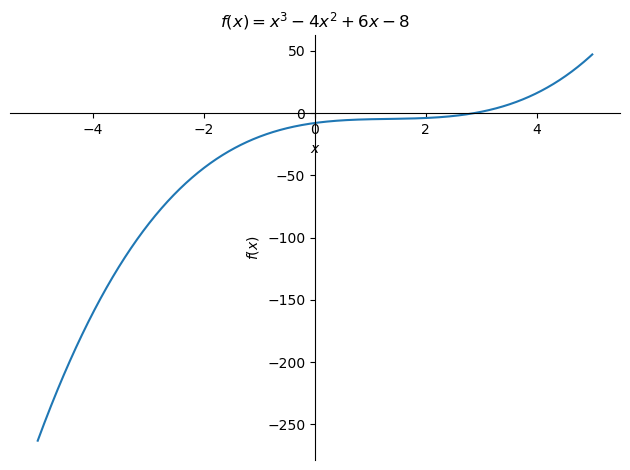

In [3]:
# 使用 Sympy 进行简单的画图分析
p = sp.plot(f, (x, -5, 5), title=r"$f(x) = x^3 - 4x^2 + 6x - 8$")

In [4]:
import numpy as np
from scipy.optimize import fsolve

# 1. 把方程定义为一个 Python 函数 (将等式一端化为 0)
def function(x):
    return x**3 - 4*x**2 + 6*x - 8

# 2. 提供一个初始猜测值 (这里体现了通用工具的代价)
# 通过上图，猜测根大概在 2.5 附近
initial_guess = 2.5

# 3. 调用 fsolve 黑盒求解
solution = fsolve(function, initial_guess)

print(f"数值解为: {solution[0]}")

数值解为: 2.881239401076398


## 3.3 求方程组的符号解和数值解

$$
\begin{cases}
x^2 - y - x = 3 \\
x + 3y = 6
\end{cases}
$$

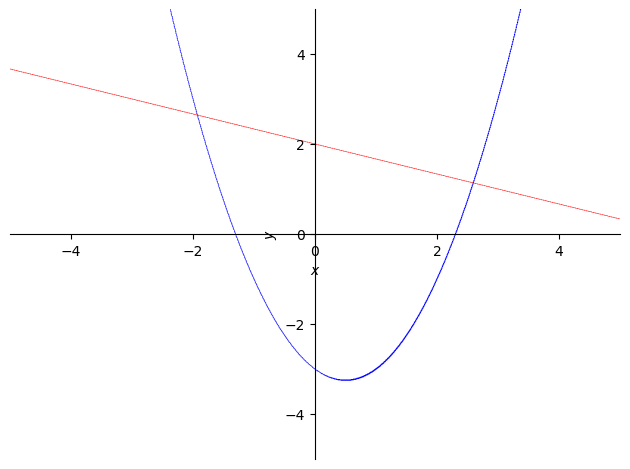

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
import sympy as sp
# 必须单独导入隐函数绘图模块
from sympy import plot_implicit, Eq

x, y = sp.symbols('x y')

# 必须用 Eq(表达式, 0) 来严格定义等式
eq1 = Eq(x**2 - y - x - 3, 0)
eq2 = Eq(x + 3*y - 6, 0)

# 分别画出两个隐函数图像，先不显示 (show=False)
p1 = plot_implicit(eq1, (x, -5, 5), (y, -5, 5), show=False, line_color='blue')
p2 = plot_implicit(eq2, (x, -5, 5), (y, -5, 5), show=False, line_color='red')

# 把第二个图“叠加”到第一个图上
p1.extend(p2)

# 最后统一显示
p1.show()

solutions = sp.solve([eq1, eq2], [x, y], dict=True)

for i, s in enumerate(solutions, start=1):
    # 注意这里的 s_{i}，下划线是为了在 LaTeX 中显示为下标
    display(Math(f's_{i} = ({sp.latex(s[x])}, {sp.latex(s[y])}) = ({s[x].evalf()}, {s[y].evalf()})'))

In [6]:
import numpy as np
from scipy.optimize import fsolve

# 1. 按照 fsolve 的规矩定义函数
def equations(vars):
    # 第一步：拆包输入。把列表里的两个元素分别赋给 x 和 y
    x, y = vars 
    
    # 第二步：将方程化为 "= 0" 的形式
    # 原方程 1: x^2 - y - x = 3  =>  x^2 - y - x - 3 = 0
    eq1 = x**2 - y - x - 3
    # 原方程 2: x + 3y = 6       =>  x + 3y - 6 = 0
    eq2 = x + 3*y - 6
    
    # 第三步：打包输出。返回这些表达式的列表
    return [eq1, eq2]

# 2. 提供初始猜测值
# 因为之前通过精确解（或画图）知道有两个交点，我们给两组不同的初始值去“抓”这两个解
guess_A = [2, 1]   # 猜测第一个点在第一象限附近
guess_B = [-2, 3]  # 猜测第二个点在第二象限附近

# 3. 调用黑盒求解
solution_A = fsolve(equations, guess_A)
solution_B = fsolve(equations, guess_B)

print(f"靠近 {guess_A} 的数值解为: x = {solution_A[0]:.4f}, y = {solution_A[1]:.4f}")
print(f"靠近 {guess_B} 的数值解为: x = {solution_B[0]:.4f}, y = {solution_B[1]:.4f}")

靠近 [2, 1] 的数值解为: x = 2.5941, y = 1.1353
靠近 [-2, 3] 的数值解为: x = -1.9274, y = 2.6425


## 3.4 求边值问题的符号解

$$
y^{\prime\prime} + y = x \cos 2x,\, y(0) = 1,\, y(2) = 3
$$

In [7]:
import sympy as sp

x = sp.symbols('x')
y = sp.Function('y')(x)

eq = sp.Eq(y.diff(x, 2) + y, x*sp.cos(2*x))
ics = {y.subs(x, 0): 1, y.subs(x, 2): 3}

solutions = sp.dsolve(eq, y, ics=ics)

display(solutions)

Eq(y(x), -x*cos(2*x)/3 + (6*cos(4) - 4*sin(4) - 9*cos(2) + 27)*sin(x)/(9*sin(2)) + 4*sin(2*x)/9 + cos(x))

## 3.5 已知

$$
\mathbf{A}_1 = \begin{bmatrix}
1 & 2 \\
3 & 4 \\
5 & 6
\end{bmatrix}
,
\mathbf{A}_1 = \begin{bmatrix}
1 & 1 \\
2 & 2 \\
3 & 4
\end{bmatrix}
,
\mathbf{A}_3 = \begin{bmatrix}
2 & 6
\end{bmatrix}
,
\mathbf{A}_4 = \begin{bmatrix}
3 & 2
\end{bmatrix}
$$

利用 Python 分块矩阵的组合，求分块矩阵 $\displaystyle\mathbf{A} = \begin{bmatrix} \mathbf{A}_1 & \mathbf{A}_2 \\ \mathbf{A}_3 & \mathbf{A}_4 \end{bmatrix}$ 的行列式 $\det(\mathbf{A})$。

In [8]:
import numpy as np

A1 = np.array([[1, 2], [3, 4], [5, 6]])
A2 = np.array([[1, 1], [2, 2], [3, 4]])
A3 = np.array([[2, 6]])
A4 = np.array([[3, 2]])

A = np.block([[A1, A2], [A3, A4]])

det_A = np.linalg.det(A)

print(f"行列式为: {det_A} = {det_A:.2f}")

行列式为: -2.55351295663785e-16 = -0.00


## 3.6 求解下列线性方程组

$$
(1) 
\begin{cases}
x_1 + 2 x_2 + x_3 - x_4 = 0 \\
3 x_1 + 6 x_2 - x_3 - 3 x_4 = 0 \\
5 x_1 + 10 x_2 + x_3 - 5 x_4 = 0
\end{cases}
\qquad
(2)
\begin{cases}
2 x + y - z + w = 1 \\
4 x + 2 y - 2 z + w = 2 \\
2 x + y - z - w = 1
\end{cases}
$$

In [9]:
import sympy as sp

x1, x2, x3, x4 = sp.symbols('x_1 x_2 x_3 x_4')

eq1 = sp.Eq(x1 + 2 * x2 + x3 - x4, 0)
eq2 = sp.Eq(3 * x1 + 6 * x2 - x3 - 3 * x4, 0)
eq3 = sp.Eq(5 * x1 + 10 * x2 + x3 - 5 * x4, 0)

solutions = sp.solve([eq1, eq2, eq3], [x1, x2, x3, x4], dict=True)
display(solutions)

[{x_1: -2*x_2 + x_4, x_3: 0}]

In [10]:
import sympy as sp

x, y, z, w = sp.symbols('x y z w')

eq1 = sp.Eq(2*x + y - z + w, 1)
eq2 = sp.Eq(4*x + 2*y - 2*z + w, 2)
eq3 = sp.Eq(2*x + y - z - w, 1)

solutions = sp.solve([eq1, eq2, eq3], [x, y, z, w], dict=True)
display(solutions)

[{w: 0, x: -y/2 + z/2 + 1/2}]

## 3.7 先判断下列方程组解的情况，然后求对应的唯一解、最小二乘解或最小范数解

$$
(1)
\begin{cases}
4 x_1 + 2 x_2 - x_3 = 2,\\
3 x_1 - x_2 + 2 x_3 = 10,\\
11 x_1 + 3 x_2 = 8;
\end{cases}
\qquad

(2)
\begin{cases}
2 x + 3y + z = 4,\\
x - 2y + 4 z = -5,\\
3 x + 8 y - 2 z = 13,\\
4 x - y + 9 z = -6.
\end{cases}
$$

In [11]:
import numpy as np

# 1. 提取左侧未知数的系数矩阵 A 和右侧的常数项向量 b
A = np.array([
    [4, 2, -1],
    [3, -1, 2],
    [11, 3, 0]
])
b = np.array([2, 10, 8])

# 2. 召唤终极黑盒 lstsq
solution, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

# 3. 核心升级：提取维度并手动计算真实误差
m, n = A.shape  # m 是方程数(行)，n 是未知数(列)
true_error = np.sum((A @ solution - b)**2)

# 设定一个极小的容差，防止浮点数计算精度问题（比如 1e-15 不等于 0）
tolerance = 1e-10 

# 4. 打印智能诊断仪表盘
print("====== 🤖 线性方程组黑盒诊断报告 ======")
with np.printoptions(precision=4, suppress=True):
    print(f"▶ 解向量输出: {solution}")
    print(f"▶ 有效线索数: {rank} (共 {n} 个未知数)")
    print(f"▶ 真实误差值: {true_error:.6f}")
    print("-" * 38)
    
    print("▶ 决策树执行逻辑与最终定性：")
    if rank == n:
        if true_error < tolerance:
            print("  ↳ 状态: Rank == n 且 误差 ≈ 0")
            print("  🎯 结论: 【唯一精确解】 (完美命中，毫无矛盾)")
        else:
            print("  ↳ 状态: Rank == n 且 误差 > 0")
            print("  ⚖️ 结论: 【唯一最小二乘解】 (条件矛盾，最佳妥协方案唯一)")
    else: # rank < n
        if true_error < tolerance:
            print("  ↳ 状态: Rank < n 且 误差 ≈ 0")
            print("  🌊 结论: 【最小范数精确解】 (存在无穷多完美解，已挑选向量最短的一个)")
        else:
            print("  ↳ 状态: Rank < n 且 误差 > 0")
            print("  🌪️ 结论: 【最小范数最小二乘解】 (条件矛盾且存在无穷多最佳妥协，已挑选向量最短的一个)")
print("=======================================")

====== 🤖 线性方程组黑盒诊断报告 ======
▶ 解向量输出: [ 1.213  -1.4478  1.9565]
▶ 有效线索数: 2 (共 3 个未知数)
▶ 真实误差值: 6.000000
--------------------------------------
▶ 决策树执行逻辑与最终定性：
  ↳ 状态: Rank < n 且 误差 > 0
  🌪️ 结论: 【最小范数最小二乘解】 (条件矛盾且存在无穷多最佳妥协，已挑选向量最短的一个)


In [12]:
import numpy as np

# 1. 提取左侧未知数的系数矩阵 A 和右侧的常数项向量 b
A = np.array([
    [2, 3, 1],
    [1, -2, 4],
    [3, 8, -2],
    [4, -1, 9]
])
b = np.array([4, -5, 13, -6])

# 2. 召唤终极黑盒 lstsq
solution, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

# 3. 核心升级：提取维度并手动计算真实误差
m, n = A.shape  # m 是方程数(行)，n 是未知数(列)
true_error = np.sum((A @ solution - b)**2)

# 设定一个极小的容差，防止浮点数计算精度问题（比如 1e-15 不等于 0）
tolerance = 1e-10 

# 4. 打印智能诊断仪表盘
print("====== 🤖 线性方程组黑盒诊断报告 ======")
with np.printoptions(precision=4, suppress=True):
    print(f"▶ 解向量输出: {solution}")
    print(f"▶ 有效线索数: {rank} (共 {n} 个未知数)")
    print(f"▶ 真实误差值: {true_error:.6f}")
    print("-" * 38)
    
    print("▶ 决策树执行逻辑与最终定性：")
    if rank == n:
        if true_error < tolerance:
            print("  ↳ 状态: Rank == n 且 误差 ≈ 0")
            print("  🎯 结论: 【唯一精确解】 (完美命中，毫无矛盾)")
        else:
            print("  ↳ 状态: Rank == n 且 误差 > 0")
            print("  ⚖️ 结论: 【唯一最小二乘解】 (条件矛盾，最佳妥协方案唯一)")
    else: # rank < n
        if true_error < tolerance:
            print("  ↳ 状态: Rank < n 且 误差 ≈ 0")
            print("  🌊 结论: 【最小范数精确解】 (存在无穷多完美解，已挑选向量最短的一个)")
        else:
            print("  ↳ 状态: Rank < n 且 误差 > 0")
            print("  🌪️ 结论: 【最小范数最小二乘解】 (条件矛盾且存在无穷多最佳妥协，已挑选向量最短的一个)")
print("=======================================")

====== 🤖 线性方程组黑盒诊断报告 ======
▶ 解向量输出: [ 0.3333  1.3333 -0.6667]
▶ 有效线索数: 2 (共 3 个未知数)
▶ 真实误差值: 0.000000
--------------------------------------
▶ 决策树执行逻辑与最终定性：
  ↳ 状态: Rank < n 且 误差 ≈ 0
  🌊 结论: 【最小范数精确解】 (存在无穷多完美解，已挑选向量最短的一个)


## 3.8 求下列矩阵的特征值和特征向量:

$$
\begin{bmatrix}
6 & 2 & 4 \\
2 & 3 & 2 \\
4 & 2 & 6
\end{bmatrix}.
$$

In [13]:
import sympy as sp
from IPython.display import display, Math

# 1. 定义符号矩阵
A_sym = sp.Matrix([
    [6, 2, 4],
    [2, 3, 2],
    [4, 2, 6]
])

# 2. 召唤特征值/特征向量黑盒
eigen_info = A_sym.eigenvects()

# 3. 优雅地打印数学家给出的结果
for val, mult, vectors in eigen_info:
    print(f"特征值: {val} (重数: {mult})")
    for i, vec in enumerate(vectors):
        display(Math(f'特征向量_{i+1} = {sp.latex(vec)}'))
    print("-" * 30)

特征值: 2 (重数: 2)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

------------------------------
特征值: 11 (重数: 1)


<IPython.core.display.Math object>

------------------------------


## 3.9 已知二次型 $f=x_1^2 + x_2^2 + x_3^2 + 2a x_1 x_2 + 2 x_1 x_2 + 2 x_1 x_3 + 2b x_2 x_3$ 经过正交变换化为标准形 $f=y_2^2 + 2y_3^2$，求参数 $a,b$ 及所用的正交交换矩阵。

In [14]:
import sympy as sp
from IPython.display import display, Math

# 1. 定义未知的符号参数，并明确告诉黑盒它们是实数 (real=True)
a, b = sp.symbols('a b', real=True)
lam = sp.symbols('lambda')

# 2. 提取并构建含有未知参数的对称矩阵 A
# 注意：交叉项系数记得除以 2，2(a+1) 提取进矩阵就是 a+1
A = sp.Matrix([
    [1, a+1, 1],
    [a+1, 1, b],
    [1, b, 1]
])

# 3. 召唤特征多项式黑盒，构建方程组
# ① 计算机推导出的带参数的多项式：det(lambda*I - A)
char_poly_A = A.charpoly(lam).as_expr()

# ② 根据题意目标特征值 (0, 1, 2) 反推出来的多项式
target_poly = (lam - 0) * (lam - 1) * (lam - 2)
# 展开它：lambda^3 - 3*lambda^2 + 2*lambda
target_poly = sp.expand(target_poly) 

# ③ 提取两个多项式的系数并让它们一一对应相等
# char_poly_A 展开大概是 lam^3 - 3*lam^2 + c1*lam + c2
# 我们提取一次项(lam)和常数项构建方程
coeffs_A = sp.Poly(char_poly_A, lam).all_coeffs()
coeffs_target = sp.Poly(target_poly, lam).all_coeffs()

eq1 = sp.Eq(coeffs_A[2], coeffs_target[2]) # 对应 lam 的一次项系数
eq2 = sp.Eq(coeffs_A[3], coeffs_target[3]) # 对应常数项

# 4. 求解参数 a 和 b
solution = sp.solve([eq1, eq2], [a, b], dict=True)
print("🎯 破译出来的参数为:")
print(solution)

# 提取唯一的实数解，代回原矩阵
sol_dict = solution[0]
A_real = A.subs(sol_dict)

print("\n⚙️ 参数代入后，真实的矩阵 A 为:")
display(Math(sp.latex(A_real)))

# 5. 求正交变换矩阵 P
# 我们需要严格按照特征值 0, 1, 2 的顺序来排列列向量
P_columns = []
eigen_info = A_real.eigenvects()

print("\n🚀 开始拼装正交变换矩阵 P (特征向量单位化):")
for target_val in [0, 1, 2]:
    for val, mult, vecs in eigen_info:
        if val == target_val:
            # 取出特征向量
            vec = vecs[0]
            # 最关键的一步：单位化（除以它自己的长度 norm）
            normalized_vec = vec / vec.norm()
            P_columns.append(normalized_vec)

# 将三个列向量横向拼接 (hstack) 成最终的正交矩阵
P = sp.Matrix.hstack(*P_columns)
display(Math(sp.latex(P)))

🎯 破译出来的参数为:
[{a: -1, b: 0}]

⚙️ 参数代入后，真实的矩阵 A 为:


<IPython.core.display.Math object>


🚀 开始拼装正交变换矩阵 P (特征向量单位化):


<IPython.core.display.Math object>

## 3.10 画出 $\cos\sqrt{x^2 + 1}$ 及它在 $0$ 点处的 $1,3,5$ 阶泰勒展开式在 $x\in [-3,3]$ 时的图形

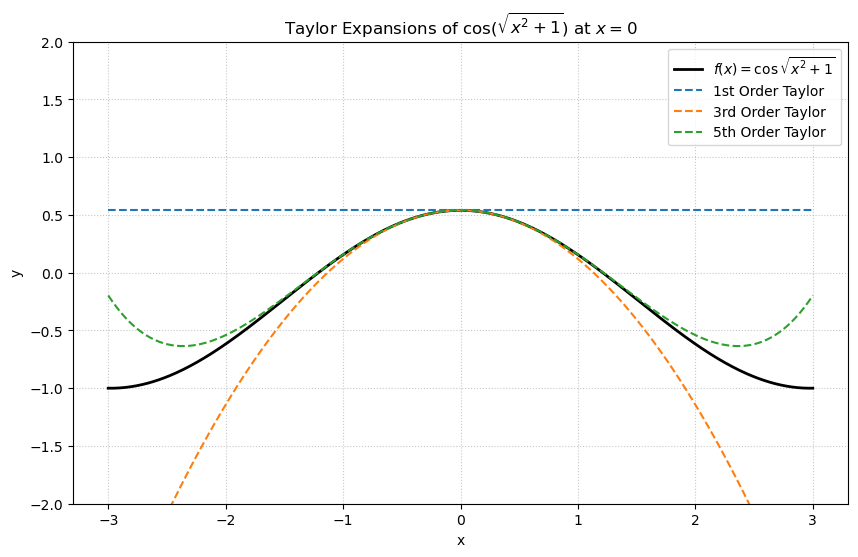

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# 1. 定义符号变量和函数
x = sp.Symbol('x')
f_expr = sp.cos(sp.sqrt(x**2 + 1))

# 2. 计算 1, 3, 5 阶泰勒展开式
def get_taylor_poly(expr, n):
    # series(expr, x, x0, n+1) 计算到 O(x^(n+1))，即最高项为 x^n
    return expr.series(x, 0, n + 1).removeO()

p1 = get_taylor_poly(f_expr, 1)
p3 = get_taylor_poly(f_expr, 3)
p5 = get_taylor_poly(f_expr, 5)

# 3. 转换为数值函数
f_func = sp.lambdify(x, f_expr, 'numpy')
p1_func = sp.lambdify(x, p1, 'numpy')
p3_func = sp.lambdify(x, p3, 'numpy')
p5_func = sp.lambdify(x, p5, 'numpy')

# 4. 生成绘图数据
x_vals = np.linspace(-3, 3, 500)
y_f = f_func(x_vals)

# 处理常数项展开式的情况（确保返回数组而非标量）
def eval_poly(p_func, x_v):
    res = p_func(x_v)
    return np.full_like(x_v, res) if np.isscalar(res) else res

y_p1 = eval_poly(p1_func, x_vals)
y_p3 = eval_poly(p3_func, x_vals)
y_p5 = eval_poly(p5_func, x_vals)

# 5. 绘图
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_f, 'k-', label=r'$f(x)=\cos\sqrt{x^2+1}$', linewidth=2)
plt.plot(x_vals, y_p1, '--', label='1st Order Taylor')
plt.plot(x_vals, y_p3, '--', label='3rd Order Taylor')
plt.plot(x_vals, y_p5, '--', label='5th Order Taylor')

plt.title(r'Taylor Expansions of $\cos(\sqrt{x^2+1})$ at $x=0$')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim([-2, 2]) # 限制 y 轴范围以便观察
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

## 3.11 一只兔子在坐标位置 $(20,0)$ (单位：m) 处以速率 $v_r = 3 \text{ m/s}$ 沿平行于 $y$ 轴正向的方向奔跑；与此同时，一只猎狗在坐标原点处以速率 $v_d=4.5 \text{ m/s}$ 追击兔子。猎狗在追击兔子的过程中，方向始终朝着兔子的当前位置。请绘制猎狗追击兔子的近似曲线，并估计追击时间。

追击成功！估计时间: 7.93 秒
抓到位置: (20.00, 23.70)


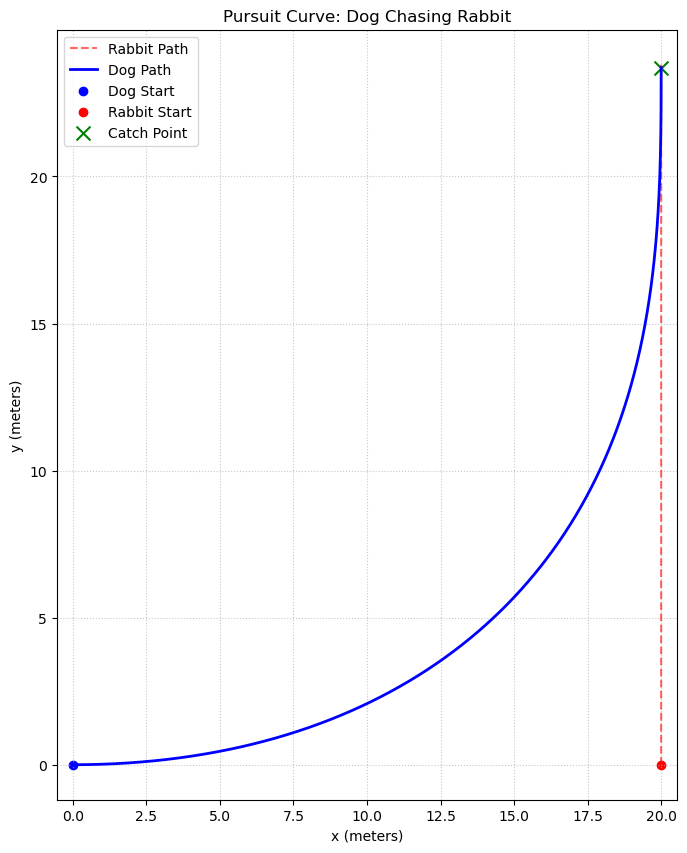

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
vr = 3.0      # 兔子速率 (m/s)
vd = 4.5      # 猎狗速率 (m/s)
x0, y0 = 0, 0 # 猎狗初始位置
xr = 20       # 兔子初始 x 坐标 (固定)
dt = 0.001     # 时间步长 (s)
max_time = 20 # 最大模拟时间

# 初始化数据容器
t_list = [0]
dog_pos = [[x0, y0]]
rabbit_pos = [[xr, 0]]

# 数值模拟
t = 0
x, y = x0, y0
while t < max_time:
    # 1. 计算当前兔子位置
    yr = vr * t
    
    # 2. 计算距离和方向
    dx = xr - x
    dy = yr - y
    distance = np.sqrt(dx**2 + dy**2)
    
    # 3. 检查是否抓到（距离小于一个很小的值）
    if distance < 0.1:
        print(f"追击成功！估计时间: {t:.2f} 秒")
        print(f"抓到位置: ({x:.2f}, {y:.2f})")
        break
        
    # 4. 猎狗向兔子方向移动
    # 猎狗速度在 x 和 y 方向的分量
    vx = vd * (dx / distance)
    vy = vd * (dy / distance)
    
    # 5. 更新猎狗位置
    x += vx * dt
    y += vy * dt
    t += dt
    
    # 保存轨迹
    t_list.append(t)
    dog_pos.append([x, y])
    rabbit_pos.append([xr, yr])

# 转换为 numpy 数组方便绘图
dog_pos = np.array(dog_pos)
rabbit_pos = np.array(rabbit_pos)

# 绘图
plt.figure(figsize=(8, 10))
plt.plot(rabbit_pos[:, 0], rabbit_pos[:, 1], 'r--', label='Rabbit Path', alpha=0.6)
plt.plot(dog_pos[:, 0], dog_pos[:, 1], 'b-', label='Dog Path', linewidth=2)

# 标记起点和终点
plt.scatter([0], [0], color='blue', marker='o', label='Dog Start')
plt.scatter([20], [0], color='red', marker='o', label='Rabbit Start')
plt.scatter(dog_pos[-1, 0], dog_pos[-1, 1], color='green', marker='x', s=100, label='Catch Point')

plt.title("Pursuit Curve: Dog Chasing Rabbit")
plt.xlabel("x (meters)")
plt.ylabel("y (meters)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.axis('equal')
plt.show()

追击完成！
估计追击时间: 8.1500 秒
抓到位置: (20.01, 24.41)


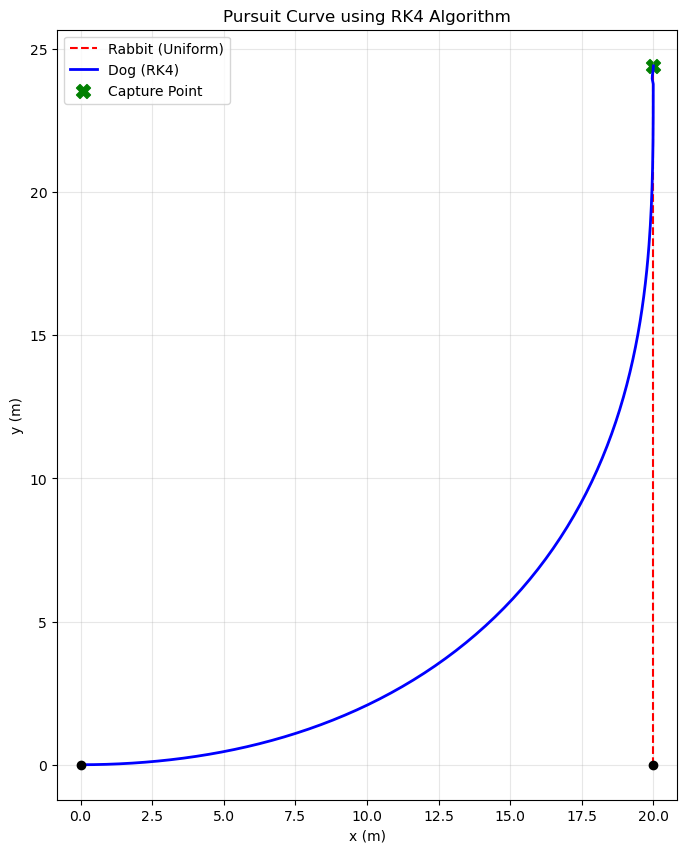

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- 参数定义 ---
vr = 3.0      # 兔子速率
vd = 4.5      # 猎狗速率
xr_const = 20 # 兔子 x 坐标固定为 20
dt = 0.05     # 步长 (RK4 允许步长稍大，精度依然很高)
max_time = 30 # 最大搜索时间

# --- 导数函数 ---
def f(t, p):
    """
    p[0] 为狗的 x, p[1] 为狗的 y
    返回 [dx/dt, dy/dt]
    """
    x, y = p
    yr = vr * t  # 当前兔子 y 坐标
    
    dx = xr_const - x
    dy = yr - y
    dist = np.sqrt(dx**2 + dy**2)
    
    # 防止除以 0（抓到时距离极小）
    if dist < 1e-5:
        return np.array([0.0, 0.0])
    
    return np.array([vd * dx / dist, vd * dy / dist])

# --- 初始化 ---
t = 0.0
p = np.array([0.0, 0.0]) # 猎狗初始位置 (0, 0)
history_dog = [p.copy()]
history_rabbit = [np.array([xr_const, 0.0])]

# --- RK4 迭代循环 ---
catch_time = None
while t < max_time:
    # 检查是否追上（距离小于阈值）
    dist_now = np.sqrt((xr_const - p[0])**2 + (vr * t - p[1])**2)
    if dist_now < 0.05:
        catch_time = t
        break
        
    # 计算 RK4 四个斜率
    k1 = f(t, p)
    k2 = f(t + dt/2, p + dt/2 * k1)
    k3 = f(t + dt/2, p + dt/2 * k2)
    k4 = f(t + dt, p + dt * k3)
    
    # 更新位置
    p = p + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    t += dt
    
    history_dog.append(p.copy())
    history_rabbit.append(np.array([xr_const, vr * t]))

# --- 结果展示 ---
history_dog = np.array(history_dog)
history_rabbit = np.array(history_rabbit)

print(f"追击完成！")
if catch_time:
    print(f"估计追击时间: {catch_time:.4f} 秒")
    print(f"抓到位置: ({p[0]:.2f}, {p[1]:.2f})")

# 绘图
plt.figure(figsize=(8, 10))
plt.plot(history_rabbit[:,0], history_rabbit[:,1], 'r--', label='Rabbit (Uniform)')
plt.plot(history_dog[:,0], history_dog[:,1], 'b-', label='Dog (RK4)', linewidth=2)
plt.scatter([0, xr_const], [0, 0], c='black', zorder=5) # 起点
plt.scatter(p[0], p[1], color='green', marker='X', s=100, label='Capture Point')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Pursuit Curve using RK4 Algorithm')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

## 3.12 分别求下列积分的数值解：

$(1) \int_0^{+\infty} e^{-x} \sin \sqrt{x^2 + 2} dx;$

$(2) \iint_D (x^2 + 2 y^2) dx dy,$ 其中 $D$ 是由曲线 $x=y^2,\, y=x-2$ 所围成的平面区域;

$(3)\iiint_\Omega z dxdydz,$ 其中 $\Omega$ 是由曲面 $z=x^2+y^2$ 与平面 $z=4$ 所围成的闭区间.

In [18]:
import numpy as np
from scipy.integrate import quad, dblquad, tplquad

# (1) 一元广义积分
# 积分区间为 [0, +inf)
f1 = lambda x: np.exp(-x) * np.sin(np.sqrt(x**2 + 2))
res1, err1 = quad(f1, 0, np.inf)

# (2) 二元积分
# 边界：x = y^2 和 y = x - 2 (即 x = y + 2)
# 交点计算：y^2 = y + 2 => y^2 - y - 2 = 0 => (y-2)(y+1) = 0
# y 的范围是 [-1, 2]，对于固定的 y，x 的范围是 [y^2, y+2]
f2 = lambda x, y: x**2 + 2*y**2
res2, err2 = dblquad(f2, -1, 2, lambda y: y**2, lambda y: y + 2)

# (3) 三元积分
# 边界：z = x^2 + y^2 (抛物面) 和 z = 4 (平面)
# 使用柱坐标变换更高效：x = r*cos(th), y = r*sin(th), z = z
# 雅可比行列式为 r，被积函数变为 z * r
# 范围：theta [0, 2*pi], r [0, 2], z [r^2, 4]
f3 = lambda z, r, th: z * r
res3, err3 = tplquad(f3, 0, 2*np.pi, 
                     lambda th: 0, lambda th: 2, 
                     lambda th, r: r**2, lambda th, r: 4)

print(f"(1) 积分结果: {res1:.6f}")
print(f"(2) 积分结果: {res2:.6f}")
print(f"(3) 积分结果: {res3:.6f}")

(1) 积分结果: 0.832853
(2) 积分结果: 21.407143
(3) 积分结果: 67.020643


## 3.13 求函数 $f(x)=2e^{-x} \sin x$ 在 $[0,3]$ 上的极小点和极大点.

--- 运行结果 ---
极大点: x = 0.785399, f(x) = 0.644794
极小点: x = 0.000000, f(x) = 0.000000


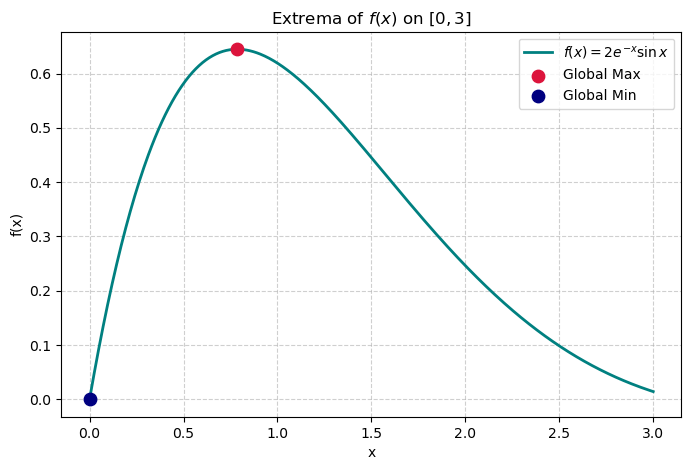

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# 1. 定义函数
def f(x):
    return 2 * np.exp(-x) * np.sin(x)

# 2. 准备候选点（极值点可能出现在导数为 0 处，也可能在边界处）
bounds = [0, 3]

# 寻找区间内部的极大值点 (通过最小化 -f(x))
res_max = minimize_scalar(lambda x: -f(x), bounds=bounds, method='bounded')
# 寻找区间内部的极小值点 (通过最小化 f(x))
res_min = minimize_scalar(f, bounds=bounds, method='bounded')

# 汇总所有可能的候选点：边界点 + 优化器找到的点
candidates = np.unique([bounds[0], bounds[1], res_max.x, res_min.x])
# 计算这些点对应的函数值
y_values = f(candidates)

# 3. 筛选绝对极大和绝对极小
idx_max = np.argmax(y_values)
idx_min = np.argmin(y_values)

final_x_max, final_y_max = candidates[idx_max], y_values[idx_max]
final_x_min, final_y_min = candidates[idx_min], y_values[idx_min]

# 4. 打印结果
print(f"--- 运行结果 ---")
print(f"极大点: x = {final_x_max:.6f}, f(x) = {final_y_max:.6f}")
print(f"极小点: x = {final_x_min:.6f}, f(x) = {final_y_min:.6f}")

# 5. 可视化
x_plot = np.linspace(bounds[0], bounds[1], 500)
plt.figure(figsize=(8, 5))

# 使用 r'' 原始字符串解决 SyntaxWarning: invalid escape sequence
plt.plot(x_plot, f(x_plot), label=r'$f(x)=2e^{-x}\sin x$', color='teal', linewidth=2)

# 标注极大点和极小点
plt.scatter(final_x_max, final_y_max, color='crimson', s=80, label='Global Max', zorder=5)
plt.scatter(final_x_min, final_y_min, color='navy', s=80, label='Global Min', zorder=5)

plt.title(r'Extrema of $f(x)$ on $[0, 3]$')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3.14 某容器内测是由曲线 $x^2+y^2=4y (1\leq y \leq 3)$ 与 $x^2+y^2=4 (y\leq 1)$ 绕 $y$ 轴旋转一周而形成的曲面.

(1) 求容器的体积;

(2) 若将容器内盛满的水从容器顶部全部抽出,至少需要做多少功?(长度单位为 $\text{m}$,重力加速度 $g=9.8 \text{ m/s}^2$,水的密度 $\rho = 10^3 \text{ kg/m}^3$).

要求画出容器的示意图.

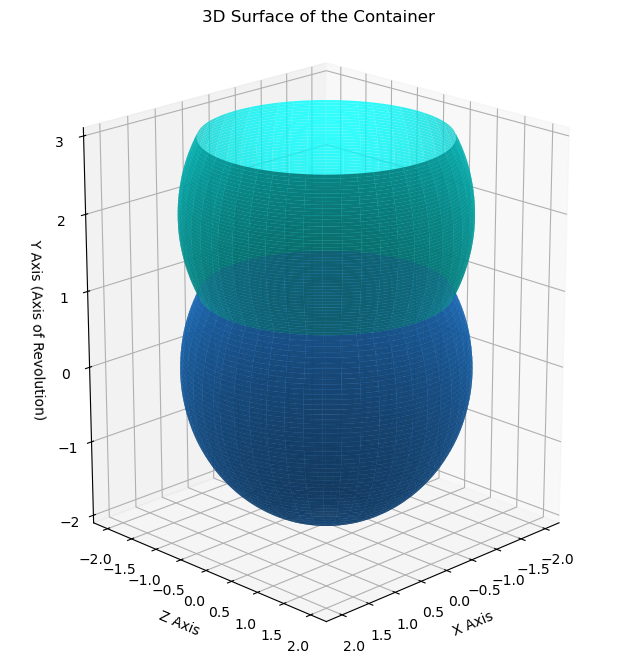

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 设定旋转角度 (0 到 2π)
theta = np.linspace(0, 2 * np.pi, 100)

# 2. 生成第一部分曲面：x^2 + y^2 = 4y (1 <= y <= 3) -> x = sqrt(4y - y^2)
y1 = np.linspace(1, 3, 50)
Theta, Y1 = np.meshgrid(theta, y1)
# 计算对应的旋转半径 R1
R1 = np.sqrt(4 * Y1 - Y1**2)
X1 = R1 * np.cos(Theta)
Z1 = R1 * np.sin(Theta)

# 3. 生成第二部分曲面：x^2 + y^2 = 4 (y <= 1) -> x = sqrt(4 - y^2)
# 半径最大为2，因此 y 下限是 -2
y2 = np.linspace(-2, 1, 50)
Theta, Y2 = np.meshgrid(theta, y2)
# 计算对应的旋转半径 R2
R2 = np.sqrt(4 - Y2**2)
X2 = R2 * np.cos(Theta)
Z2 = R2 * np.sin(Theta)

# 4. 创建 3D 图形
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制曲面 (注意坐标轴对应关系：将真实的 Y 轴放在画图的垂直 Z 轴上，更符合视觉习惯)
ax.plot_surface(X1, Z1, Y1, color='cyan', alpha=0.8, edgecolor='none', label='Upper part')
ax.plot_surface(X2, Z2, Y2, color='dodgerblue', alpha=0.8, edgecolor='none', label='Lower part')

# 5. 设置坐标轴标签和范围
ax.set_xlabel('X Axis')
ax.set_ylabel('Z Axis')
ax.set_zlabel('Y Axis (Axis of Revolution)')
ax.set_title('3D Surface of the Container')

# 设置各坐标轴比例一致，避免图形被压缩拉伸
ax.set_box_aspect((1, 1, 1.25)) 
ax.view_init(elev=20, azim=45) # 调整视角

# 显示图形
plt.show()

In [21]:
import sympy as sp

# 1. 定义符号变量
y = sp.Symbol('y')
pi = sp.pi

# 2. 定义每一段的旋转半径的平方 (x^2)
x2_lower = 4 - y**2    # 下半部分 (-2 <= y <= 1)
x2_upper = 4*y - y**2  # 上半部分 (1 <= y <= 3)

# ================= 计算 (1) 容器体积 =================
V_lower = sp.integrate(pi * x2_lower, (y, -2, 1))
V_upper = sp.integrate(pi * x2_upper, (y, 1, 3))
V_total = V_lower + V_upper

print("=== (1) 容器的体积 ===")
print(f"下半部分体积 V1 = {V_lower}")
print(f"上半部分体积 V2 = {V_upper}")
print(f"总体积 V = {V_total} 立方米\n")

# ================= 计算 (2) 抽水做功 =================
rho = 10**3  # 水的密度 1000 kg/m^3
# 避免浮点误差，使用分数表示 9.8 为 98/10
g = sp.Rational(98, 10) 

# dW = rho * g * pi * x^2 * (3 - y) dy
W_lower = sp.integrate(rho * g * pi * x2_lower * (3 - y), (y, -2, 1))
W_upper = sp.integrate(rho * g * pi * x2_upper * (3 - y), (y, 1, 3))
W_total = W_lower + W_upper

print("=== (2) 抽水所做的功 ===")
print(f"下半部分水做功 W1 = {W_lower}")
print(f"上半部分水做功 W2 = {W_upper}")
print(f"总做功精确值 W = {W_total} 焦耳")
print(f"总做功近似值 W ≈ {W_total.evalf():.2f} 焦耳")

=== (1) 容器的体积 ===
下半部分体积 V1 = 9*pi
上半部分体积 V2 = 22*pi/3
总体积 V = 49*pi/3 立方米

=== (2) 抽水所做的功 ===
下半部分水做功 W1 = 286650*pi
上半部分水做功 W2 = 215600*pi/3
总做功精确值 W = 1075550*pi/3 焦耳
总做功近似值 W ≈ 1126313.33 焦耳


## 3.15

(1) 一架重 $5000\text{ kg}$ 的飞机以 $800 \text{ km/h}$ 的航速开始着陆, 在减速伞的作用下滑行 $500 \text{ m}$ 后减速为 $100 \text{ km/h}$. 设减速伞的阻力与飞机的速度成正比,并忽略飞机所受的其他外力,试计算减速伞的阻力系数.

(2) 将同样的减速伞配备在 $8000 \text{ kg}$ 的飞机上, 现已知机场跑道长度为 $1200\text{ m}$, 若飞机着陆速度为 $600\text{ km/h}$, 问跑道长度能否保障飞机安全着陆.

In [22]:
import sympy as sp
import pint
from IPython.display import display, Math

ureg = pint.UnitRegistry()
Q_ = ureg.Quantity

x = sp.symbols('x')
v = sp.Function('v')(x)
k = sp.symbols('k')
m_val = Q_(5000, 'kg').to_base_units().magnitude
v0_val = Q_(800, 'km/h').to_base_units().magnitude
v1_val = Q_(100, 'km/h').to_base_units().magnitude

equation = sp.Eq(m_val * sp.Derivative(v, x), - k)

solution = sp.dsolve(equation, v, ics={v.subs(x, 0): v0_val})
display(solution)

v_expr = solution.rhs
eq_k = sp.Eq(v_expr.subs({x: 500}), v1_val)
display(eq_k)

result = sp.solve(eq_k, k, dict=True)[0]
display(Math(fr'k = {result[k]} \text{{ kg/s}}'))

Eq(v(x), -k*x/5000 + 222.222222222222)

Eq(222.222222222222 - k/10, 27.7777777777778)

<IPython.core.display.Math object>

In [23]:
import sympy as sp

# ==========================================
# 准备工作：定义符号
# ==========================================
x = sp.symbols('x')          # 自变量：位移
v = sp.Function('v')(x)      # 因变量：速度函数
k = sp.symbols('k')          # 待求参数：阻力系数

# ==========================================
# 第一问：求阻力系数 k
# ==========================================
# 1. 物理量定义与单位换算 (km/h -> m/s)
m1 = 5000 
v1_start = 800 / 3.6  
v1_end = 100 / 3.6    
x1 = 500              

# 2. 建立并求解第一架飞机的微分方程
eq1 = sp.Eq(m1 * sp.Derivative(v, x), -k)
sol1 = sp.dsolve(eq1, v, ics={v.subs(x, 0): v1_start})
v_expr1 = sol1.rhs

# 3. 代入已知点求 k
eq_k = sp.Eq(v_expr1.subs(x, x1), v1_end)
k_val = sp.solve(eq_k, k)[0]

print("-" * 40)
print(f"【第一问结果】")
print(f"计算得出减速伞的阻力系数 k = {k_val:.2f} kg/s")

# ==========================================
# 第二问：判断能否安全着陆
# ==========================================
# 1. 新飞机的物理量
m2 = 8000
v2_start = 600 / 3.6
runway_length = 1200

# 2. 建立新飞机的微分方程 (直接代入求出的 k_val)
eq2 = sp.Eq(m2 * sp.Derivative(v, x), -k_val)

# 3. 求解新飞机的速度随位移变化函数
sol2 = sp.dsolve(eq2, v, ics={v.subs(x, 0): v2_start})
v_expr2 = sol2.rhs

# 4. 设停下时的滑行距离为 S，建立代数方程：v(S) = 0
S = sp.symbols('S')
eq_S = sp.Eq(v_expr2.subs(x, S), 0)

# 5. 求解停止距离 S
S_val = sp.solve(eq_S, S)[0]

print("\n" + "-" * 40)
print(f"【第二问结果】")
print(f"新飞机完全停下所需的滑行距离 S = {S_val:.2f} m")

# 6. 安全性判断
if S_val <= runway_length:
    print(f"结论：因为 {S_val:.2f} m <= {runway_length} m，跑道长度足够，飞机可以安全着陆！")
else:
    print(f"结论：因为 {S_val:.2f} m > {runway_length} m，跑道长度不足，飞机会冲出跑道！")
print("-" * 40)

----------------------------------------
【第一问结果】
计算得出减速伞的阻力系数 k = 1944.44 kg/s

----------------------------------------
【第二问结果】
新飞机完全停下所需的滑行距离 S = 685.71 m
结论：因为 685.71 m <= 1200 m，跑道长度足够，飞机可以安全着陆！
----------------------------------------


## 3.16 求函数 $f(x_1,x_2)=100(x_2-x_1^2)^2+(1-\sin (x_1))^2\cos (x_2)$ 的一个局部极小点.

In [24]:
import numpy as np
from scipy.optimize import minimize

def objective_function(x):
    x1 = x[0]
    x2 = x[1]

    # term1 = 100 * (x2 - x1**2)**2
    # term2 = (1 - np.sin(x1))**2 * np.cos(x2)
    # return term1 + term2

    return 100 * (x2 - x1**2)**2 + (1 - np.sin(x1))**2 * np.cos(x2)

initial_guess = [10.0, 10.0]

result = minimize(objective_function, initial_guess, method='BFGS')

# 打印结果
if result.success:
    print("✅ 优化成功！")
    print(f"局部极小点坐标 (x1, x2): [{result.x[0]:.6f}, {result.x[1]:.6f}]")
    print(f"极小点的函数值: {result.fun:.6f}")
    print(f"迭代次数: {result.nit}")
else:
    print("❌ 优化失败，原因:", result.message)



✅ 优化成功！
局部极小点坐标 (x1, x2): [11.621539, 135.060634]
极小点的函数值: -3.276249
迭代次数: 17


In [25]:
import numpy as np
from scipy.optimize import minimize

def objective_function(x):
    x1 = x[0]
    x2 = x[1]

    # term1 = 100 * (x2 - x1**2)**2
    # term2 = (1 - np.sin(x1))**2 * np.cos(x2)
    # return term1 + term2

    return 100 * (x2 - x1**2)**2 + (1 - np.sin(x1))**2 * np.cos(x2)

initial_guess = [0.0, 0.0]

result = minimize(objective_function, initial_guess, method='Nelder-Mead')

# 打印结果
if result.success:
    print("✅ 优化成功！")
    print(f"局部极小点坐标 (x1, x2): [{result.x[0]:.6f}, {result.x[1]:.6f}]")
    print(f"极小点的函数值: {result.fun:.6f}")
    print(f"迭代次数: {result.nit}")
else:
    print("❌ 优化失败，原因:", result.message)



✅ 优化成功！
局部极小点坐标 (x1, x2): [1.317870, 1.736786]
极小点的函数值: -0.000167
迭代次数: 128
